# Libreria sdv
* Autor:Fernando Lezama Garcia
* Fecha:04 de junio

In [4]:
#importar librerias
import pandas as pd
import numpy as np
import random

In [5]:
import sdv
import sdmetrics
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [6]:
from sdmetrics.reports.single_table import QualityReport

In [7]:
print("SDV", sdv.__version__)

SDV 1.37.0


In [9]:
#creamos un dataset original que servira como fuente para crear los datos 

dfClientes = pd.DataFrame(
    {
        "Cliente:id":[1,2,3,4,5,6,7,8,9,10],
        "edad":[23,33,43,28,53,56,43,56,65,40],
        "ingreso_mensual": [25000,15000,20000,100000,50000,17000,30000,12000,35000,7500],
        "ciudad":["mexico","coauila","paso del macho","orizaba","puebla","fortin", "amatlan","Cuitlauac","Yanga","Cordoba"]
    })

In [10]:
dfClientes.head()

,Cliente:id,edad,ingreso_mensual,ciudad
0,1,23,25000,mexico
1,2,33,15000,coauila
2,3,43,20000,paso del macho
3,4,28,100000,orizaba
4,5,53,50000,puebla


In [13]:
#Definir los metadatos
metadata = SingleTableMetadata()

In [15]:
metadata.detect_from_dataframe(
    data = dfClientes
)

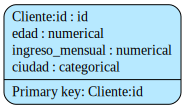

In [23]:
metadata.visualize()

In [17]:
metadata.to_dict()

{'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1',
 'primary_key': 'Cliente:id',
 'columns': {'Cliente:id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'}}}

In [30]:
# Guardamos el metadata en un archivo Json
metadata.save_to_json(
    filepath="dfClientes_metadata.json"
)

In [34]:
# Corre esta celda guardando con un nuevo nombre
metadata.save_to_json("dfClientes_metadata_v2.json")

In [35]:
synthesizer.fit(
    dfClientes
)

In [36]:
#Generamos los datos
clientes_sinteticos = synthesizer.sample(
    num_rows= 100
)

In [37]:
clientes_sinteticos.head()

,Cliente:id,edad,ingreso_mensual,ciudad
0,15976688,56,12055,puebla
1,7698778,42,63157,puebla
2,16597330,35,17906,orizaba
3,11271241,30,48273,fortin
4,3218294,52,16812,amatlan


In [39]:
dfClientesGIGO = clientes_sinteticos.copy()

In [40]:
indices = random.sample(list(dfClientesGIGO.index),5)

In [42]:
dfClientesGIGO.loc[indices, "edad"] = -5

In [43]:
#Introducir valores duplicados
duplicados = dfClientesGIGO.sample(10, random_state=42)

In [44]:
dfClientesGIGO = pd.concat([dfClientesGIGO, duplicados], ignore_index= True)

In [45]:
dfClientesGIGO.duplicated().sum()

np.int64(10)

In [46]:
dfClientesGIGO.describe(include="all")

,Cliente:id,edad,ingreso_mensual,ciudad
count,1.100000e+02,110.000000,110.000000,110
unique,NaN,NaN,NaN,10
top,NaN,NaN,NaN,mexico
freq,NaN,NaN,NaN,31
mean,7.662008e+06,40.181818,40513.027273,NaN
std,4.782121e+06,15.225029,31253.634752,NaN
min,8.294000e+03,-5.000000,12000.000000,NaN
25%,3.261974e+06,29.250000,12846.750000,NaN
50%,7.214223e+06,39.500000,33142.000000,NaN
75%,1.141242e+07,53.750000,57423.500000,NaN


In [47]:
#Generar reporte
report = QualityReport()

In [49]:
report.generate(
    real_data = dfClientes,
    synthetic_data = clientes_sinteticos,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 505.51it/s]|
Column Shapes Score: 78.0%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 157.92it/s]|
Column Pair Trends Score: 20.0%

Overall Score (Average): 49.0%



In [50]:
report.generate(
    real_data = dfClientes,
    synthetic_data = dfClientesGIGO,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 558.29it/s]|
Column Shapes Score: 75.15%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 234.09it/s]|
Column Pair Trends Score: 9.55%

Overall Score (Average): 42.35%

